# [LAB-11] 시계열 분석ㅣ03-분해 시계열(실습코드).ipynb

# 분해 시계열이란 
시계열을 추세, 계절, 잔차로 쪼개어 각각을 따로 들여다보는 방법 

새로운 기법이 아니라, 이동평균을 체계적으로 활용한 것 \
탐색적 데이터분석 DEA에 해당한다 

## #01. 준비작업 

### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import *

from pandas import DataFrame 
import numpy as np
import seaborn as sb

# 시계열 분해 
from statsmodels.tsa.seasonal import seasonal_decompose 

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 불러오기 + 시계열 인덱스 설정 

In [2]:
origin = load_data('air_passengers')

# 월단위 데이터임을 알림 -> freq = "MS" (Month Start)   
df = my_ts.set_index(origin, "Month", freq="MS")
print("인덱스 간격(freq) : ", df.index.freqstr)
df.head()

📚 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)
인덱스 간격(freq) :  MS


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## # 가법 모델과 승법 모델 
성분이 더해져 있는지 곱해져 있는지에 따라 구분 

계절 변동폭이 일정하면 가법, 추세에 비례하면 승법 -> 모델 유형에 따라 분해 방법이 달라진다. 

## # 어떤 모델을 쓸 것인가 - 데이터로 판단한다. 
연도별 평균, 표준편차, 변동계수(표준편차/ 평균) -> 최대/최소 비율 확인

표준편차는 커지는데 변동계수가 일정하면 승법 모델 

1) 표준편차가 일정 -> 가법 모델 

2) 표준편차는 커지는데 변동계수 일정 -> 승법 모델 

## #02. 분해 시계열( Decompositoin )
### 1. 어떤 모델을 쓸 것인가 - 데이터로 판단하기 

연도별 변동폭이 커지는지 확인하면 된다. 

1단원에서 만든 report_variation() 함수가 이 질문에도 그대로 답한다. 

In [3]:
# 기간 단위 (기본 freq="YE" -> 연 단위)로 묶어 평균, 표준편차, 변동계수를 계산한다. 
# 변동계수 = 표준편차 / 평균 . 승법이면 이 값이 일정하다. 
# 판정 문장은 함수가 출력하고, 표는 반환되므로 마지막 줄에 놓아 화면에 띄운다. 
my_ts.report_variation(df, "Passengers", freq="YE")

표준편차 최대/최소: 5.67배
변동계수 최대/최소: 1.56배
판정: 변동폭이 수준에 비례한다 -> 로그변환 권장 / 승법(multiplicative)모델


,평균,표준편차,변동계수
기간,,,
1949-12-31,126.667,13.720,0.108
1950-12-31,139.667,19.071,0.137
1951-12-31,170.167,18.438,0.108
1952-12-31,197.000,22.966,0.117
1953-12-31,225.000,28.467,0.127
1954-12-31,238.917,34.924,0.146
1955-12-31,284.000,42.140,0.148
1956-12-31,328.250,47.862,0.146
1957-12-31,368.417,57.891,0.157


# 결과 확인 
판단규칙 \
표준편차가 일정 -> 가법모델 \
표준편차는 커지는데 변동계수(표준편차/평균)가 일정 -> 승법 모델 

이 데이터는 후자이므로 승법 모델을 쓴다. 

### 2. 분해 시계열 생성 
statsmodels의 seasonal_decompose()가 세 성분(추세, 계절, 잔차)을 한번에 계산한다.\
model파라미터에 가법모델additive 또는 승법모델 multiplicative 여부를 지정해야 함 

분해는 차분하기 전의 원본으로 하는 것이 원칙이다. \
차분은 추세와 계절성을 지우는 작업인데, 분해는 그 추세와 계절성을 보려는 것이기 때문이다. 

In [4]:
# 분해 수행 -> 분해할 시계열, 모델 유형( 승법/ 가법 ), 계절 주기(period)
# 반환값은 'observed', 'trend', 'seasonal', 'resid' 네 개의 Series를 속성으로 가진 객체 
result = seasonal_decompose(df["Passengers"], model='multiplicative', period=12)

# 비교와 저장이 편하도록 데이터프레임 하나로 묶어서 사용 (인덱스는 원본과 동일)
sd = DataFrame({
    "origin": result.observed, # 원본 시계열
    "trend": result.trend, #추세 성분 ( 장기적 방향)
    "seasonal": result.seasonal, # 계절 성분 (주기적 반복)
    "resid": result.resid, # 잔차 성분( 설명되지 않는 변동) 
})

sd.dropna() 

,origin,trend,seasonal,resid
Month,,,,
1949-07-01,148.000,126.792,1.227,0.952
1949-08-01,148.000,127.250,1.220,0.953
1949-09-01,136.000,127.958,1.060,1.002
1949-10-01,119.000,128.583,0.922,1.004
1949-11-01,104.000,129.000,0.801,1.006
...,...,...,...,...
1960-02-01,391.000,461.375,0.884,0.959
1960-03-01,419.000,465.208,1.007,0.894
1960-04-01,461.000,469.333,0.976,1.006


# 결과확인 

trend, resid의 앞 뒤 6개월은 결측치다. 

추세를 12개월 이동평균으로 계산하므로 양 끝에서는 평균 낼 값이 부족하기 때문이다. 

sd.dropna()로 확인하면 144개월 중 132개월만 남는다. 

### 3. 분해된 성분 시각화 

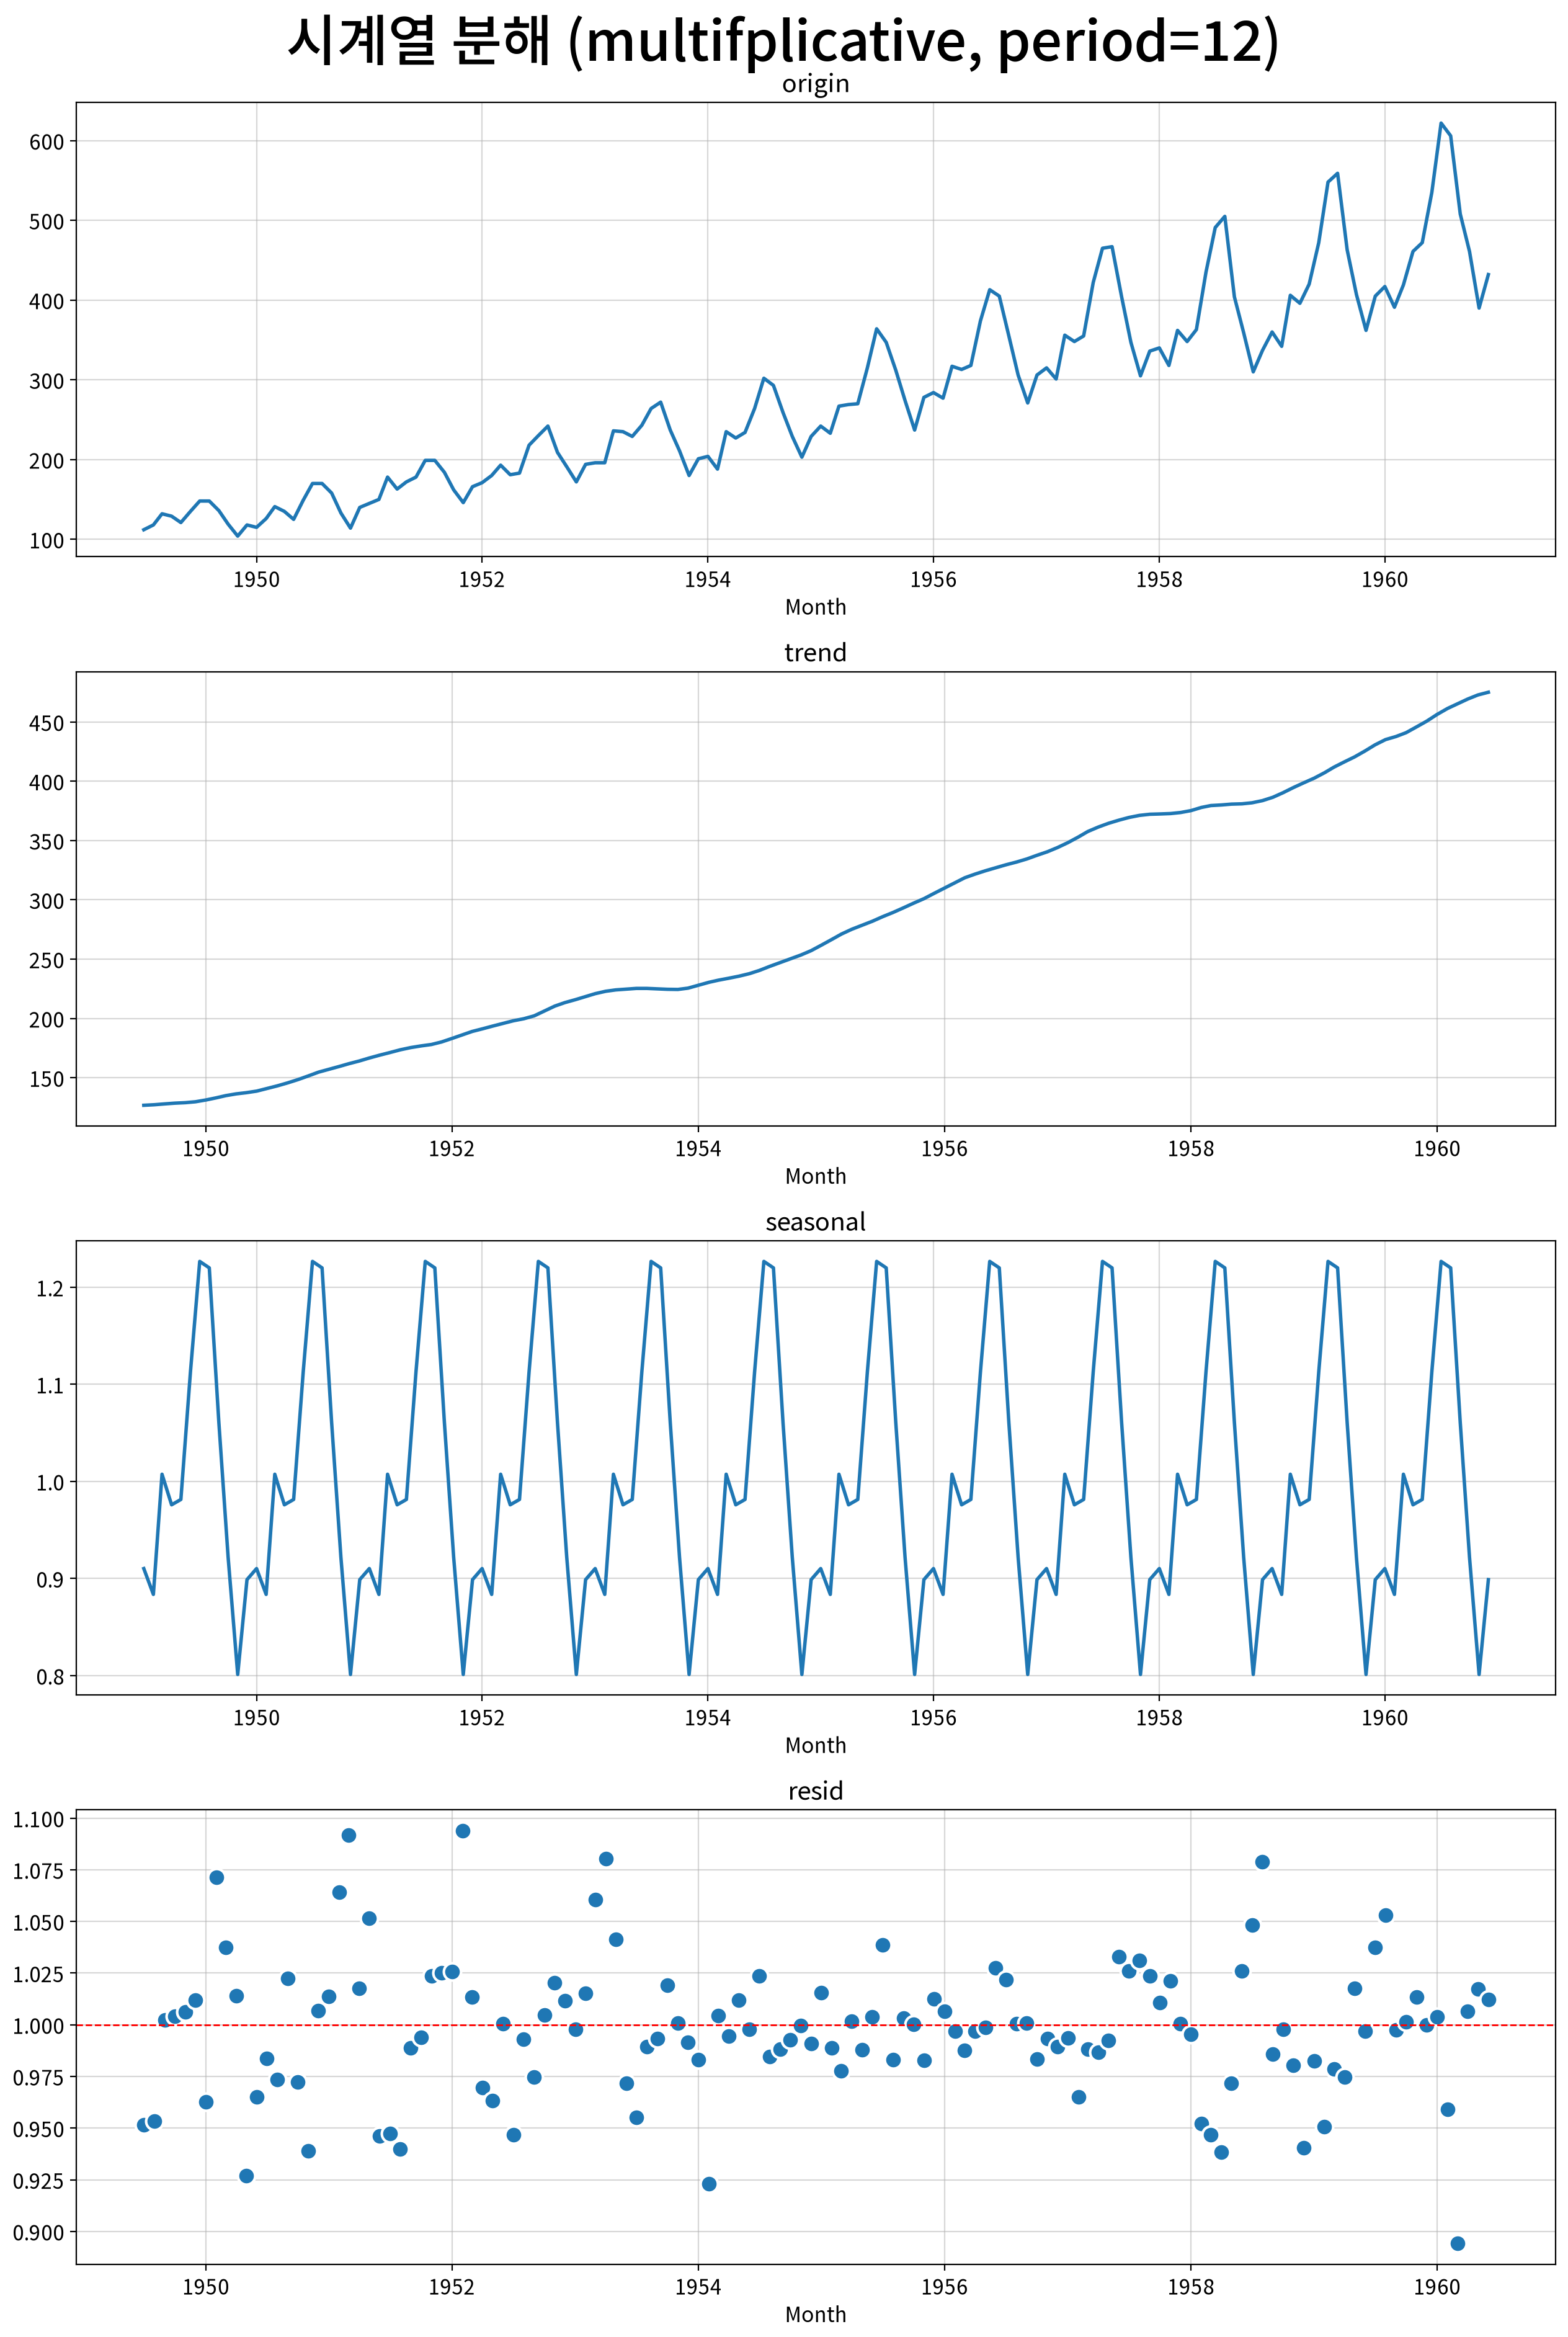

In [5]:
# 성분별로 한 단씩, 4단 그래프로 그린다. 
fig, ax = my_plot.init(rows=4, cols=1, width=1280, height=480, 
                       title="시계열 분해 (multifplicative, period=12)") 

for i, col in enumerate(sd.columns):
    if col == "resid": 
        # 잔차는 불규칙 하므로 점으로 그려야 남은 패턴이 보인다. 
        my_plot.scatterplot(data=sd, x=sd.index, y=col, ax=ax[i])

    else: 
        my_plot.lineplot(x=sd.index, y=sd[col], ax=ax[i])

    ax[i].set_title(col)
    ax[i].set_ylabel("")

# 승법 모델의 잔차 기준선은 1 (가법 모델이면 0)
ax[3].axhline(1, color="red", linestyle="--", linewidth=1)

my_plot.show()


# 결과확인 

승법 모델이므로 계절 성분은 배수로 읽는다. seasonal=1.227은 추세선보다 22.7% 높다는 뜻.\
잔차가 1 주변에 몰려 있으면 분해가 잘 된 신호\
패턴이 남아있다면 주기를 잘못 잡았거나 모델 선택이 틀린 것. 

## #03. 분해 시계열의 특성 
### 1. 추세와 이동평균 비교 - 이동평균 구하기 

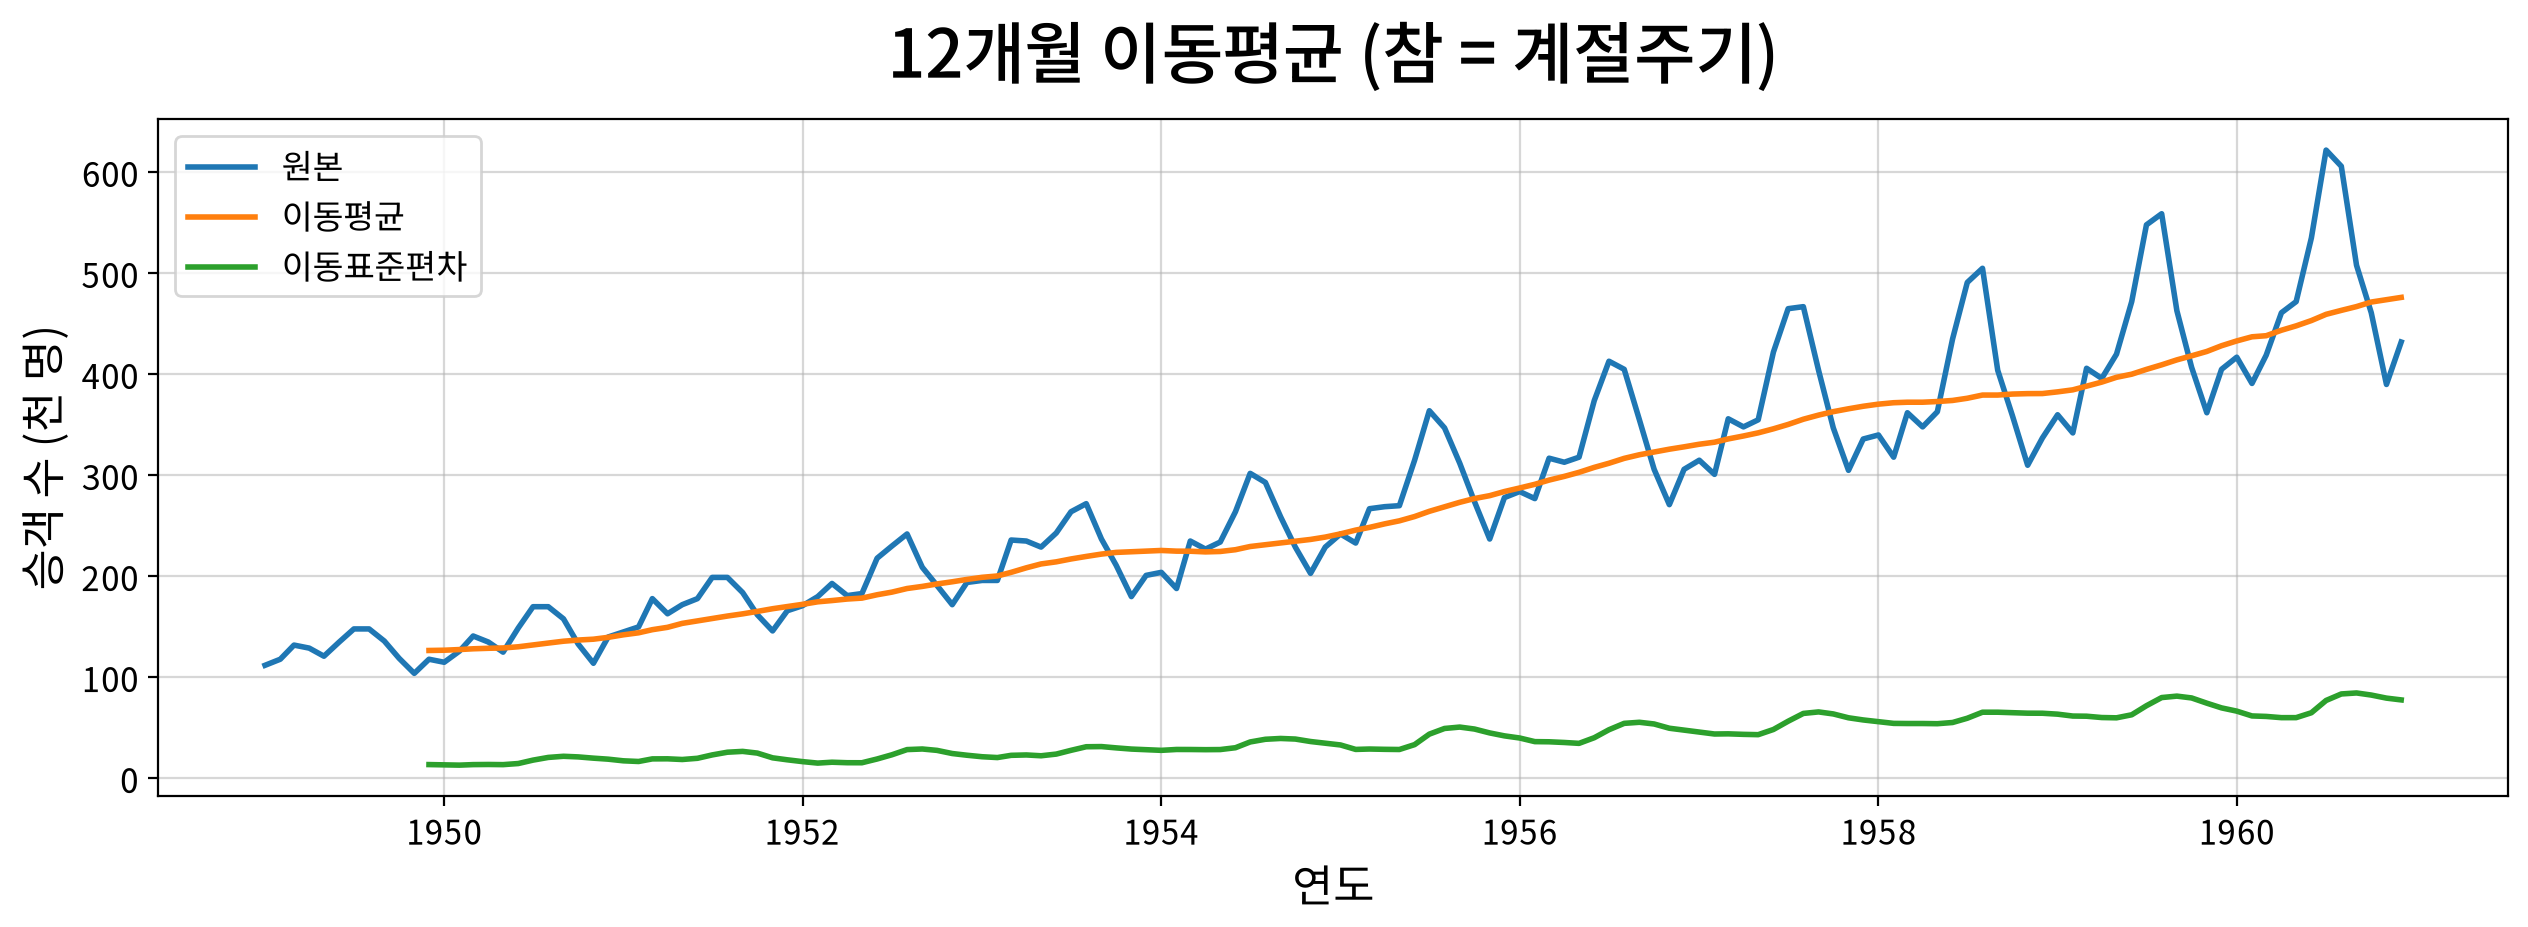

,원본,이동평균,이동표준편차
Month,,,
1949-01-01,112,NaN,NaN
1949-02-01,118,NaN,NaN
1949-03-01,132,NaN,NaN
1949-04-01,129,NaN,NaN
1949-05-01,121,NaN,NaN


In [6]:
# 2단원에서 만든 함수로 12개월 이동평균을 구한다. 
# --> 리턴값이 이동평균이 계산된 데이터프레임
rolling = my_ts.plot_rolling(df, 12, "Passengers", 
                             title="12개월 이동평균 (참 = 계절주기)", 
                             xlabel="연도", ylabel="승객 수 (천 명)")

rolling.head()

### 2. 추세와 이동평균 비교 - 추세와 이동평균의 상관계수 확인 

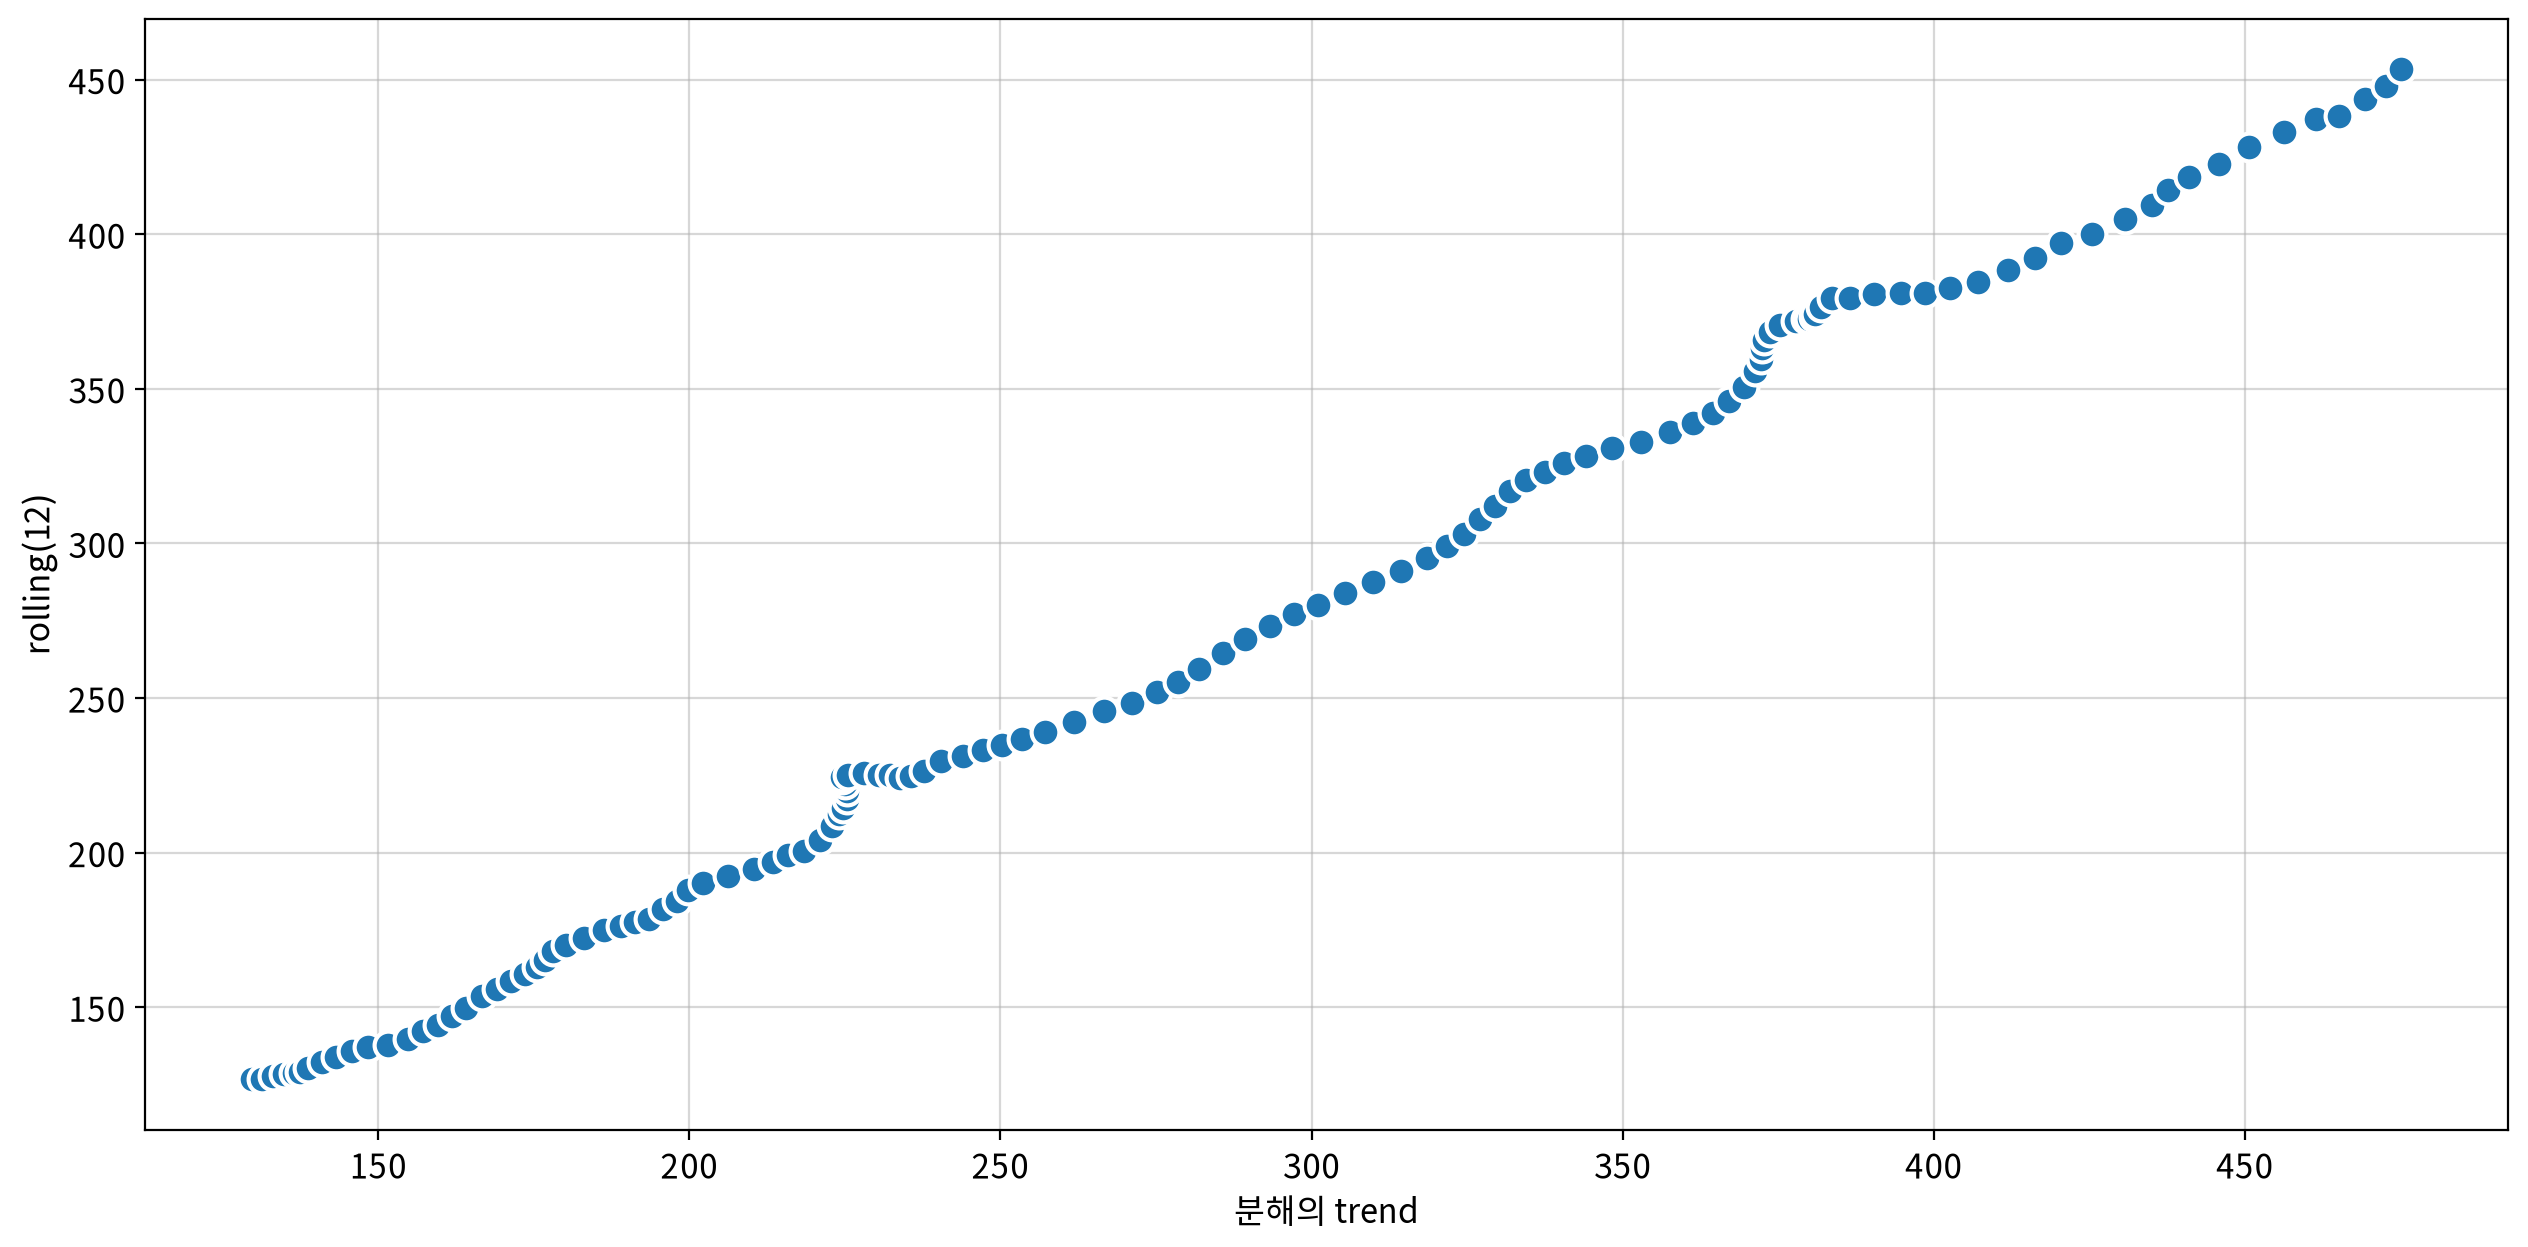

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
분해의 trend,rolling(12),Spearman,1.000,0.000,Strong,True,False,False,True,False,False


In [7]:
# 분해가 내놓은 추세 성분과 나란히 노ㅠ고 비교한다. 
check = DataFrame({
    "분해의 trend": sd["trend"], 
    "rolling(12)": rolling["이동평균"],
})

# 두 값의 상관계수 확인 
my_stats.correlation(check, "분해의 trend", "rolling(12)")

# 결과 확인 

상관계수가 1이다. 
p< 0.05 

상관이 있는 정도가 아니라, 동일한 정보라고 보는 것이 타당하다 

### 3. 계절 성분의 특성 

계절 성분은 매년 똑같이 반복되므로 1년치만 뽑아보면 전체를 알 수 있다. 

In [8]:
# 계절 성분에서 1년치(12개월)만 추출하여 월별로 정리 
season = sd["seasonal"].groupby(sd.index.month).first() 
season.index.name = "월"
sdf = DataFrame({"계절지수": season.round(4)})

# 계절지수의 평균은 1이어야 한다. (승법 모델 기준)
sdf["평균"] = season.mean().round(4)

# 승법 모델은 원본 = 추세 x 계절 x 잔차 이므로 계절지수는 배수이다. 
# 기준점이 1(=추세와 똑같음)이므로 , 1을 빼면 기준에서 얼마나 벗어났는지가 되고 ,
# x100 하면 백분율이 된다. 
# 즉, 추세대비 몇 % 증감인지를 의미한다. 
sdf["추세 대비"] = ((season -1)*100).round(1).astype(str) + "%" 

sdf.T

월,1,2,3,4,5,6,7,8,9,10,11,12
계절지수,0.910,0.884,1.007,0.976,0.981,1.113,1.227,1.220,1.060,0.922,0.801,0.899
평균,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
추세 대비,-9.0%,-11.6%,0.7%,-2.4%,-1.9%,11.3%,22.7%,22.0%,6.0%,-7.8%,-19.9%,-10.1%


### 4. 계절 성분의 특성 - 추세 대비 시각화 

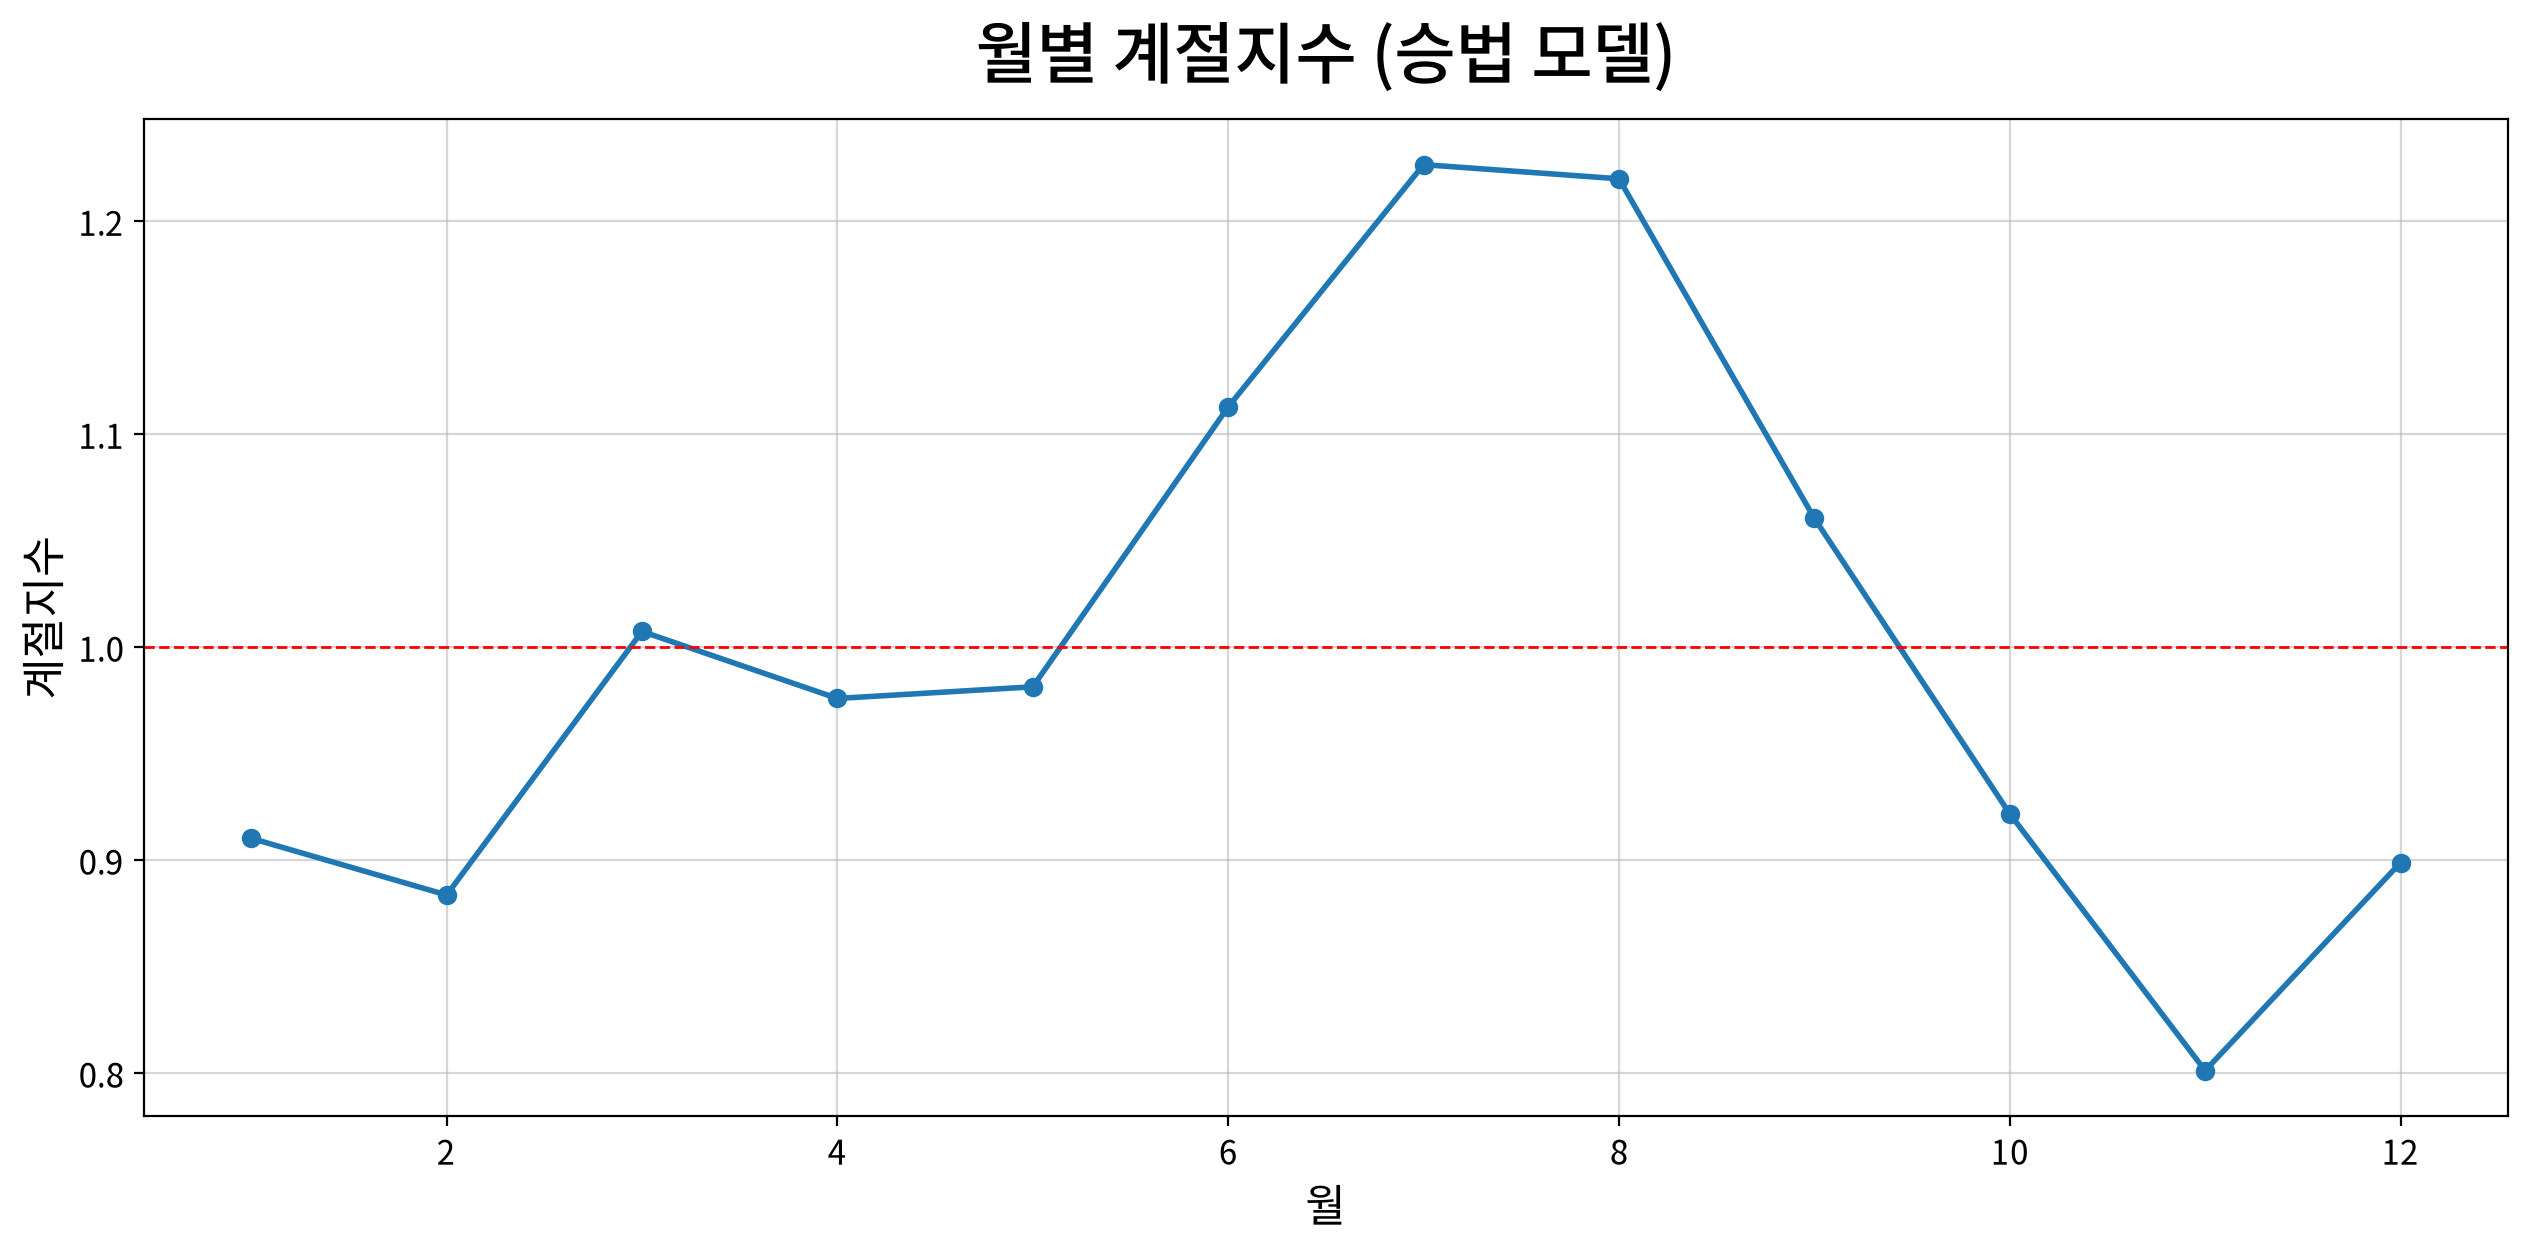

In [9]:
# 그래프 초기화 
fig, ax = my_plot.init(title="월별 계절지수 (승법 모델)", 
                       xlabel="월", ylabel="계절지수")

# 캔버스(ax)에 추세 대비를 선 그래프로 표시 
my_plot.lineplot(x=season.index, y=season.values, marker="o", ax=ax)

# 승법 모델 기준 평균성(=1)을 표시 
ax.axhline(1, color = "red", linestyle="--", linewidth=1)

# 그래프 화면 출력 
my_plot.show()

### 결과 확인 

1) 성수기, 비수기 구분

2) 계절성의 진폭 

3) 여름 한 덩어리 

4) 인접 달 비율 

### 5. 계절 조정 시계열 만들기 
원본에서 계절 성분을 걷어내면 계절 요인을 제거한 나머지 움직임이 남는다. 

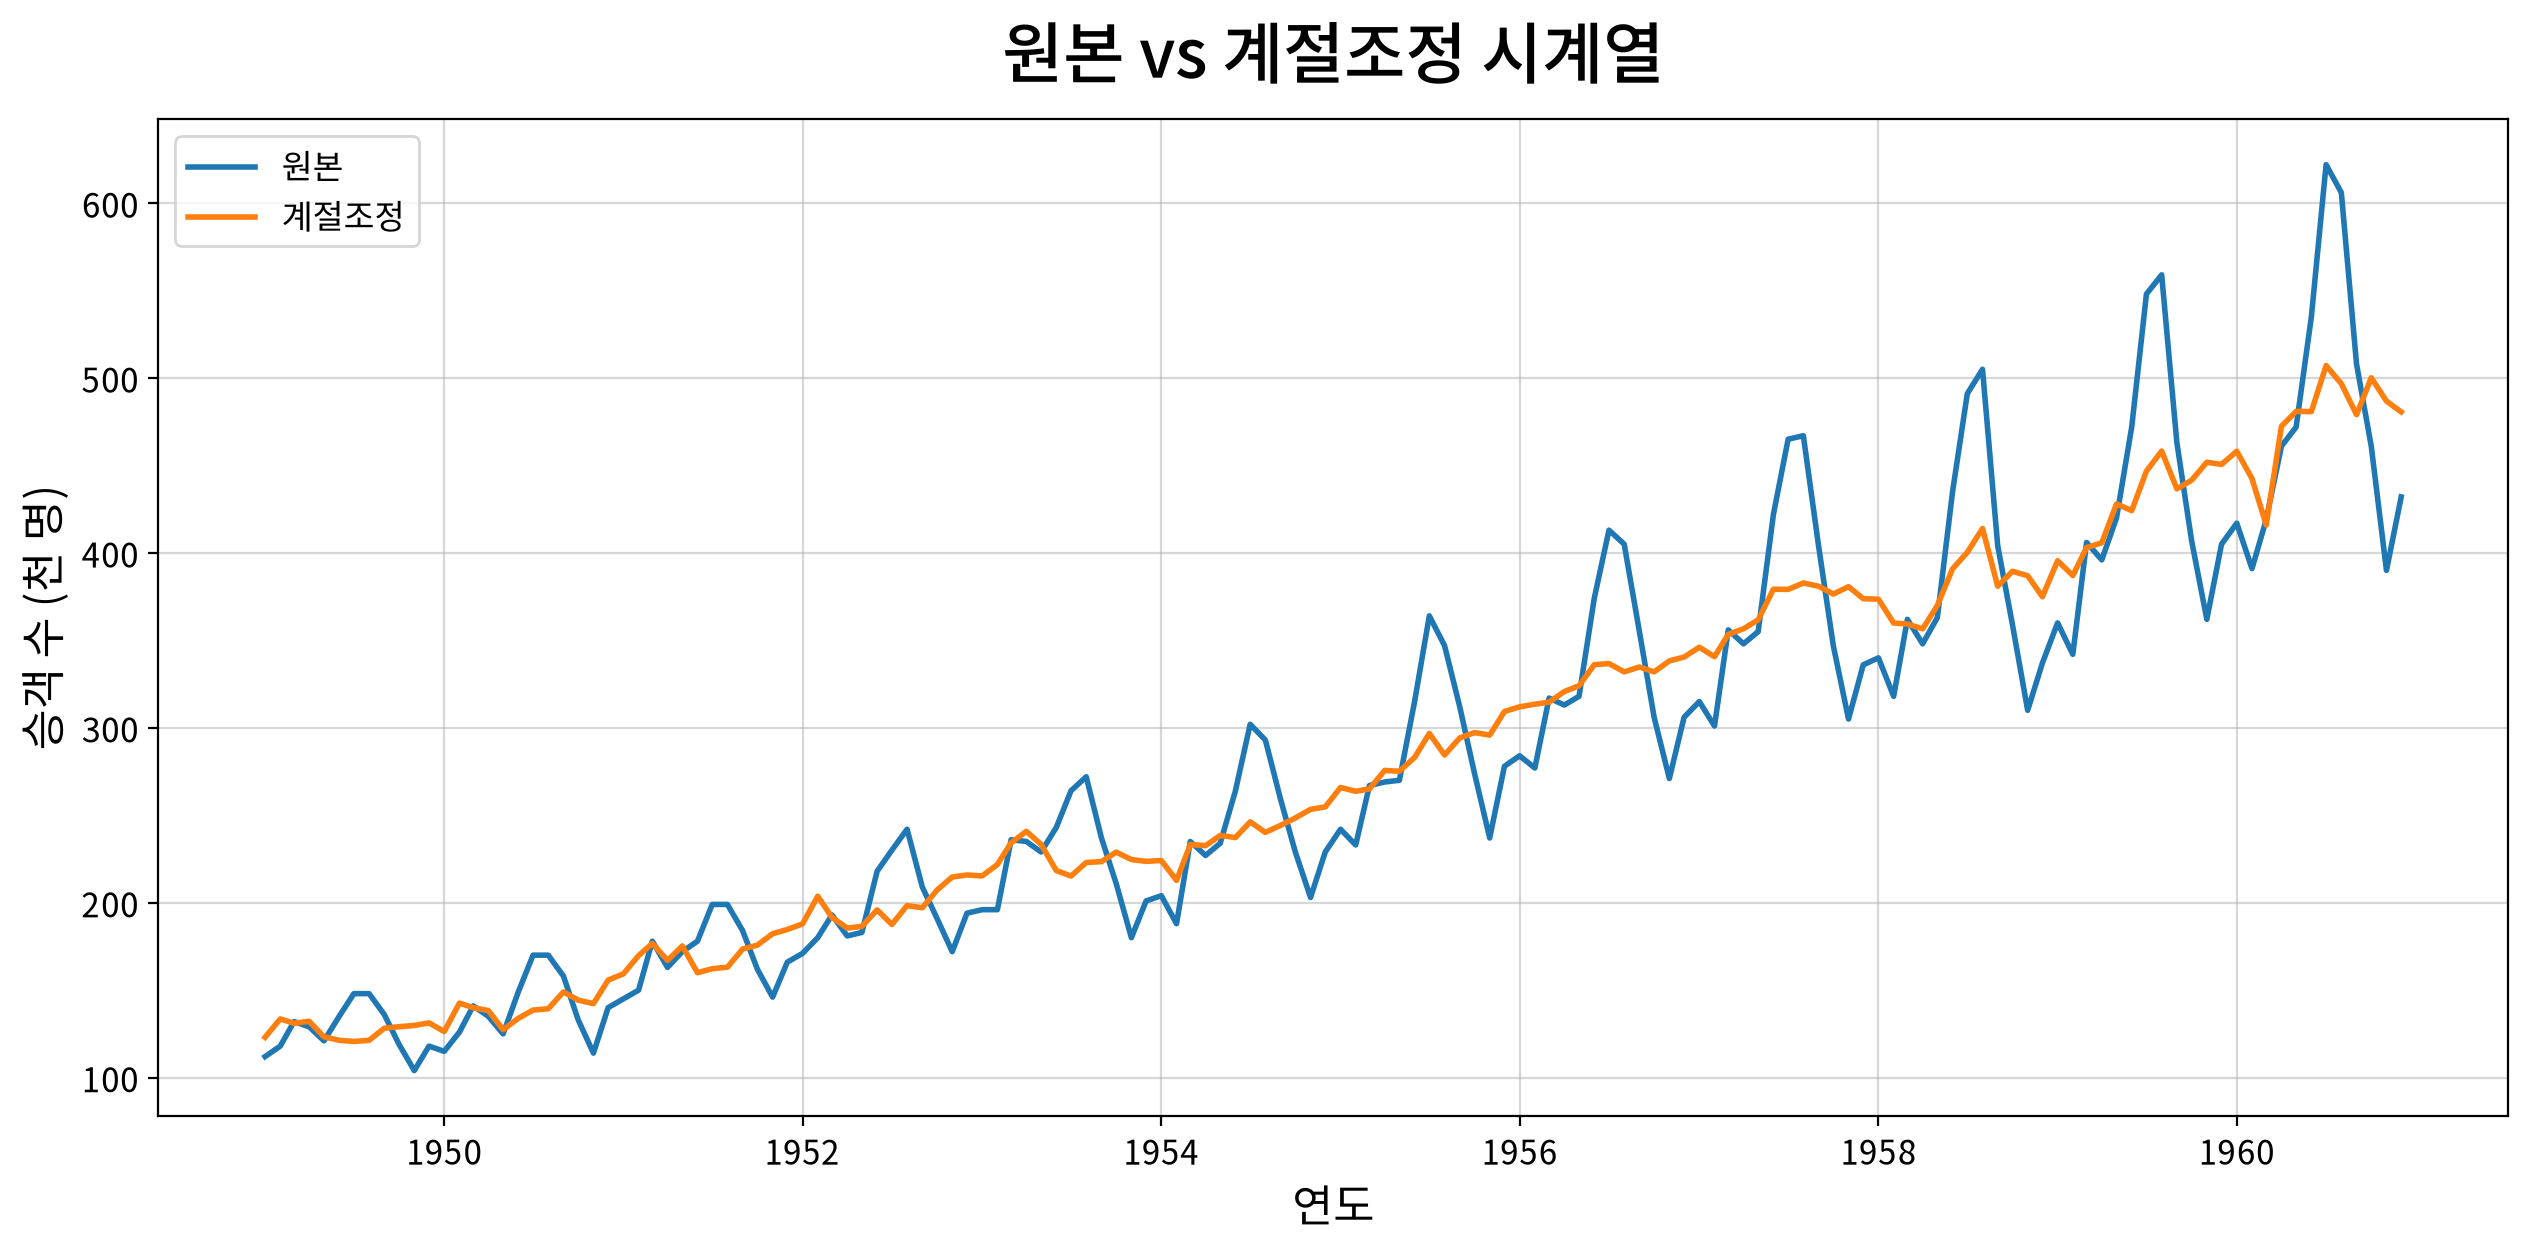

In [10]:
# 승법 모델이므로 나누기로 계절 성분을 제거한다 (가법이면 빼기)
adjusted = sd["origin"] / sd["seasonal"]

fig, ax = my_plot.init(title="원본 vs 계절조정 시계열", 
                       xlabel="연도", ylabel="승객 수 (천 명)" )

my_plot.lineplot(x=df.index, y=df["Passengers"], label="원본", ax=ax)
my_plot.lineplot(x=sd.index, y=adjusted, label="계절조정", ax=ax)

ax.legend()
my_plot.show()

# 2. 분해 시계열 모듈화 

## #04. 모듈화 기능 확인 

### 1. 분해 시계열 생성 

결합 방식 자동 판정: multiplicative
관측치 144개 중 추세, 잔차가 계산된 구간 132개


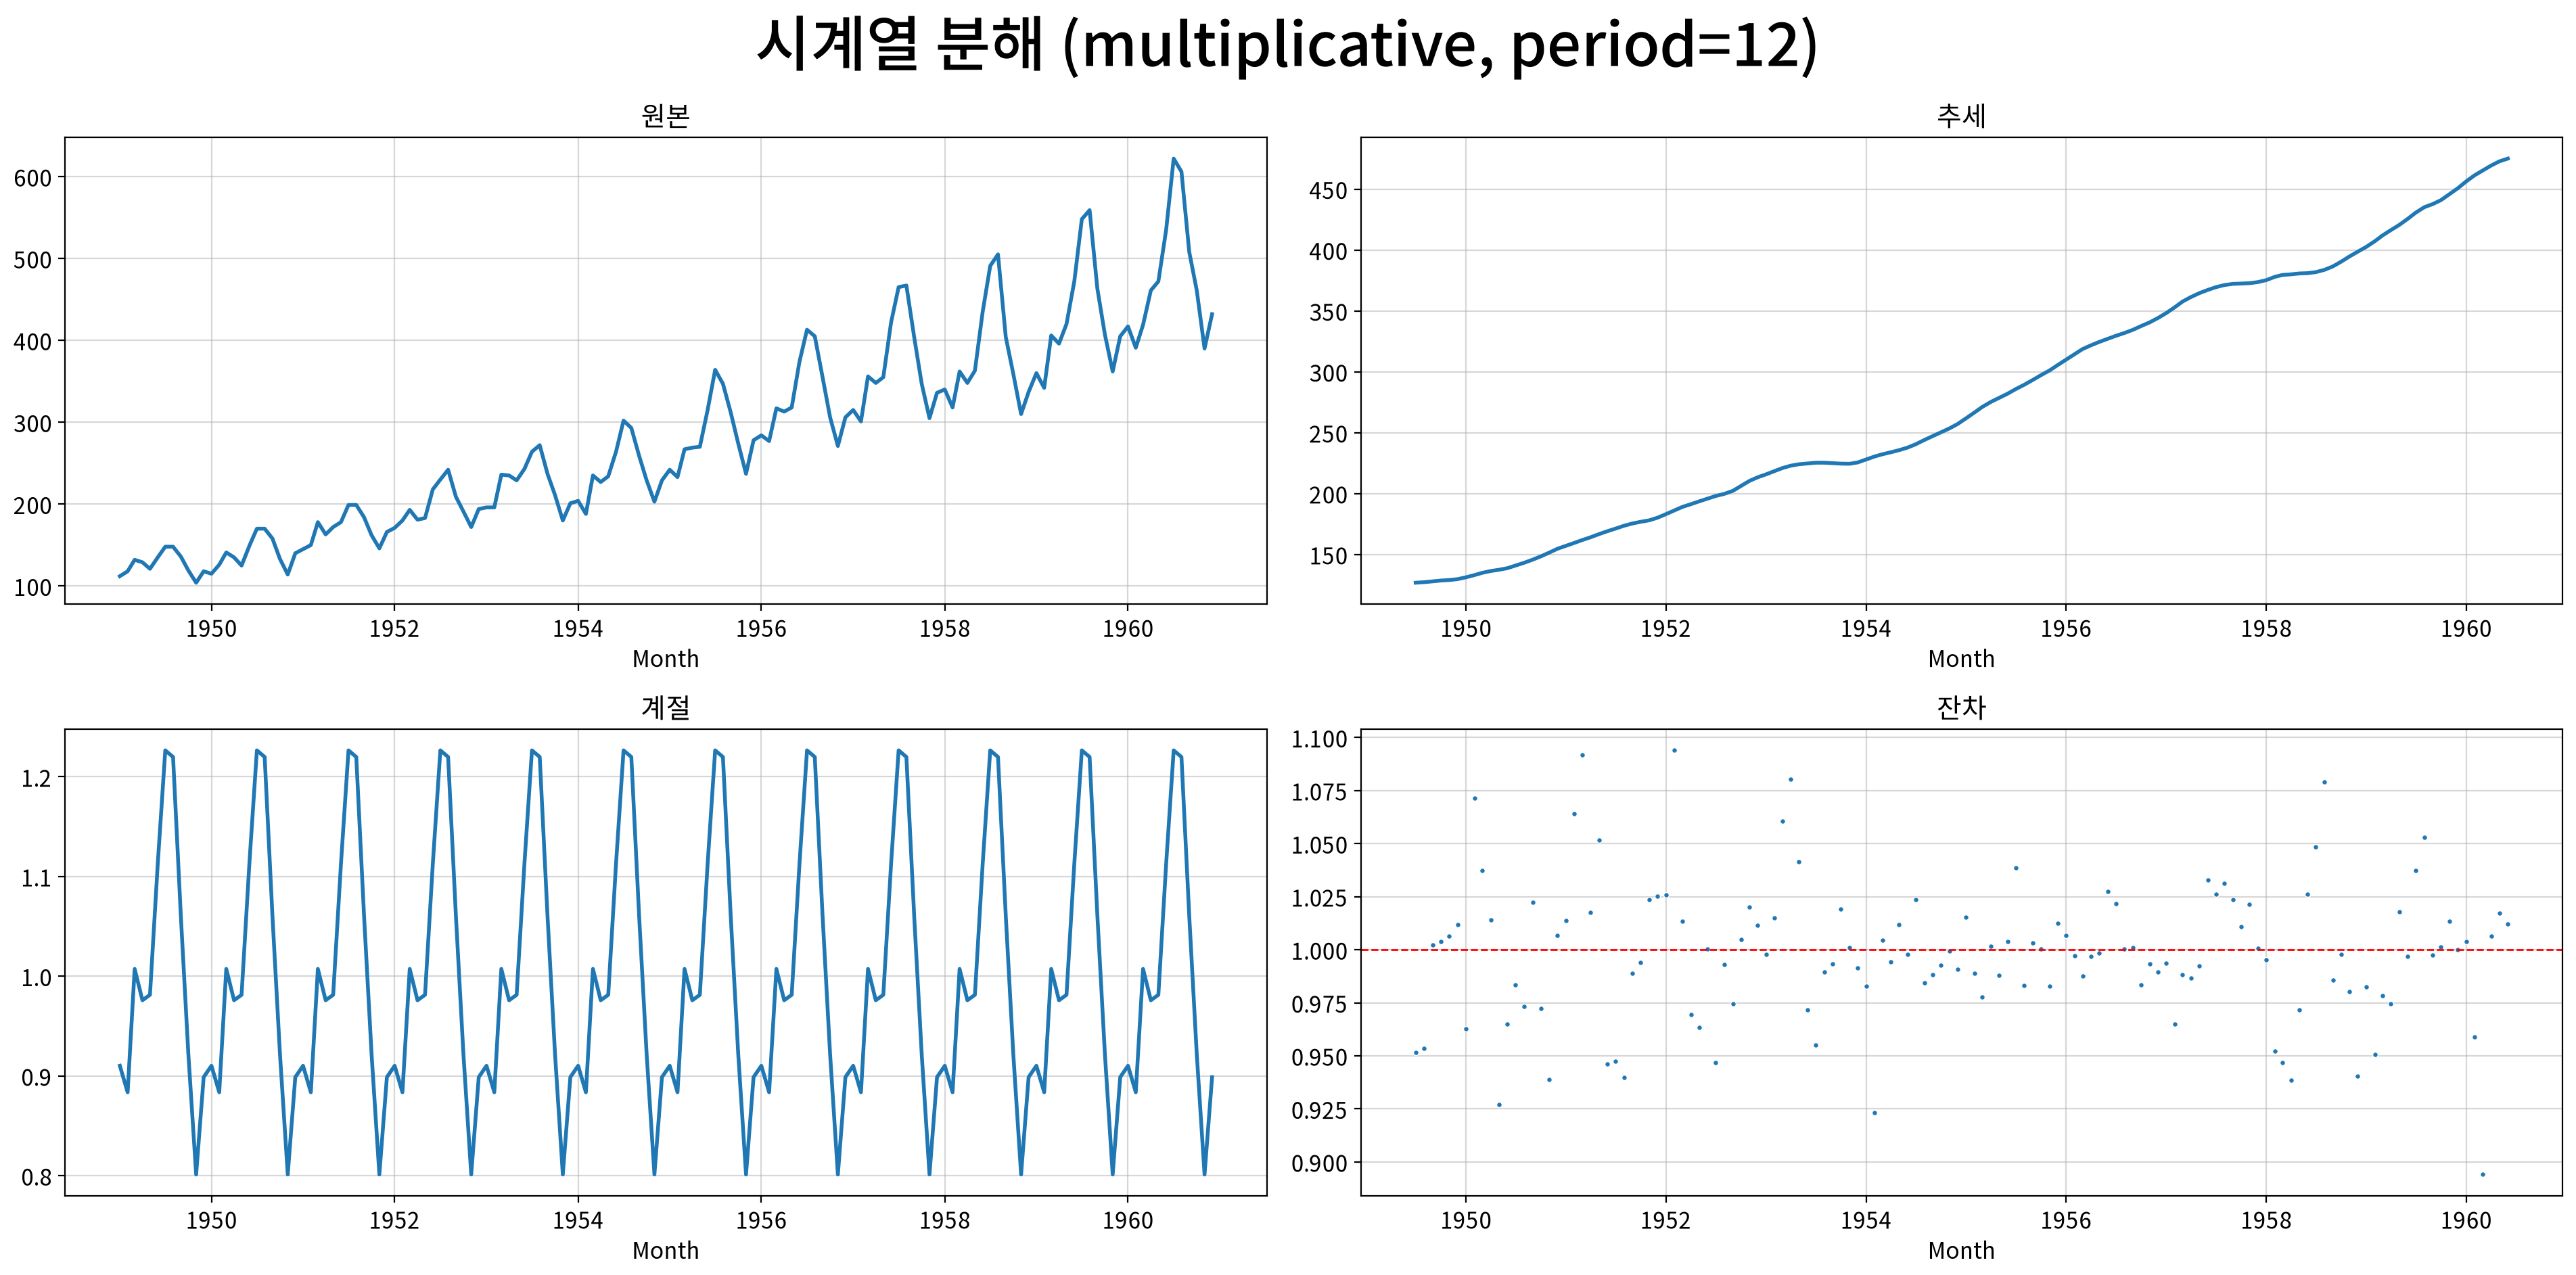

,원본,추세,계절,잔차
Month,,,,
1949-07-01,148.000,126.792,1.227,0.952
1949-08-01,148.000,127.250,1.220,0.953
1949-09-01,136.000,127.958,1.060,1.002


In [11]:
# model을 주지 않으면 가법/승법을 스스로 판정한다 
result = my_ts.decompose(df, 12, "Passengers")

# 표는 화면에 뿌려지지 않고 반환되므로, 보고 싶으면 마지막 줄에 놓는다. 
result.dropna().head(3)

### 2. 계절지수 

결합 방식: multiplicative
최고 위치: 7 (1.2266)
최저 위치: 11 (0.8012)


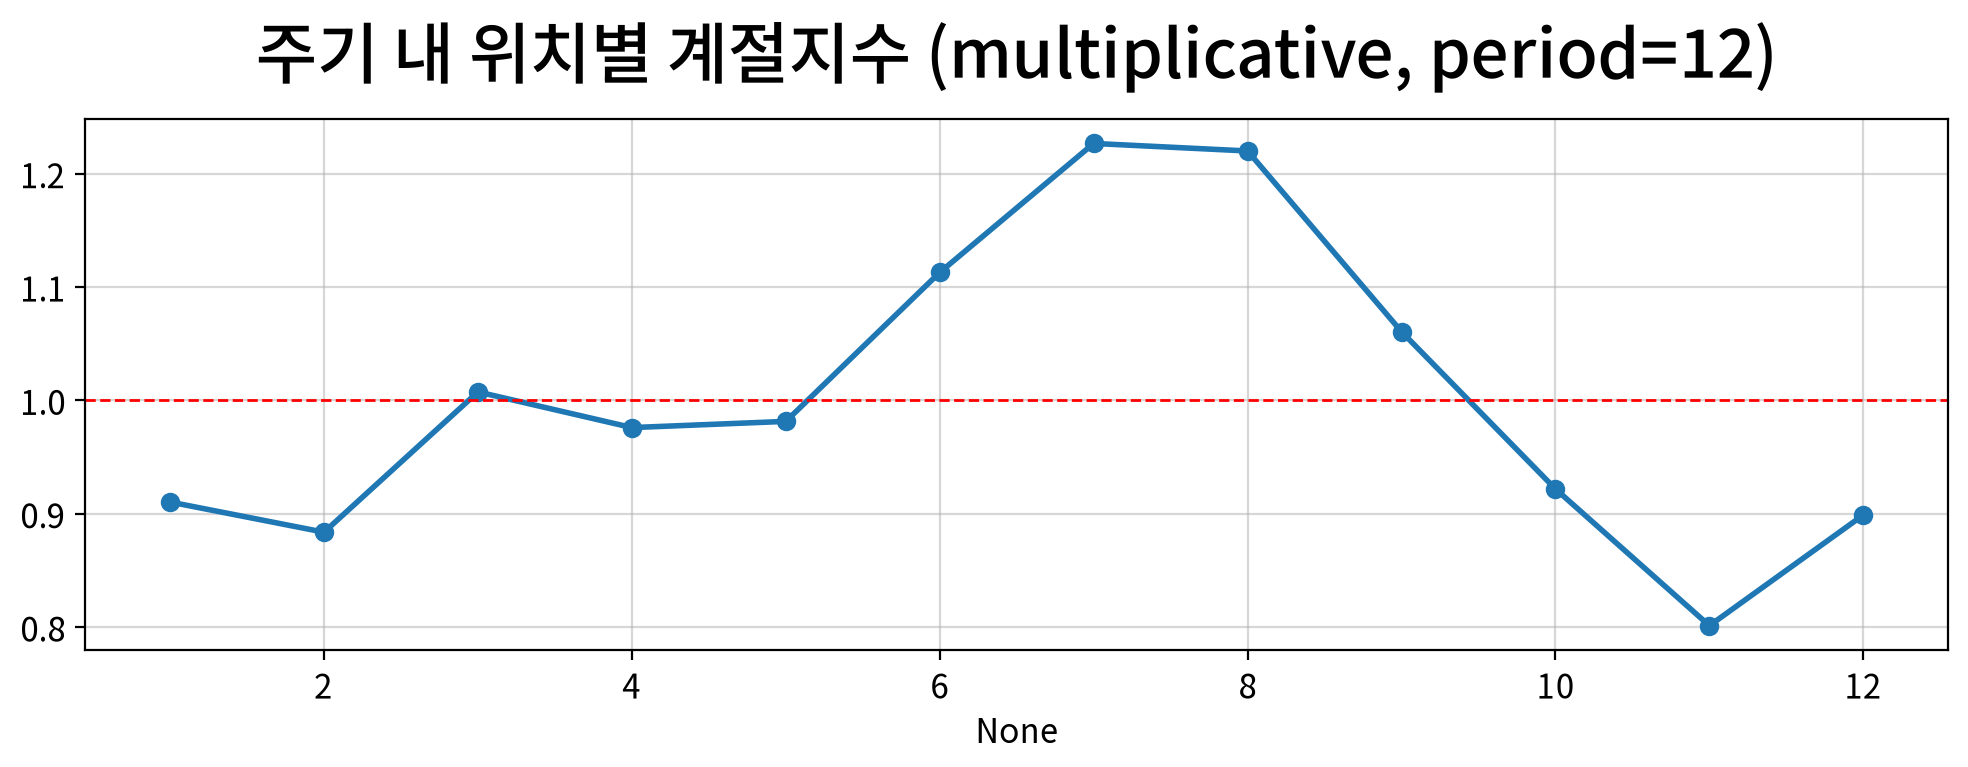

주기 내 위치,1,2,3,4,5,6,7,8,9,10,11,12
계절지수,0.910,0.884,1.007,0.976,0.981,1.113,1.227,1.220,1.060,0.922,0.801,0.899
평균,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
기준 대비(%),-9.000,-11.600,0.700,-2.400,-1.900,11.300,22.700,22.000,6.000,-7.800,-19.900,-10.100


In [12]:
ss = my_ts.report_seasonal(df, 12, "Passengers")
ss.T

### 3. 계절 조정 

결합방식: multiplicative (원본 / 계절)


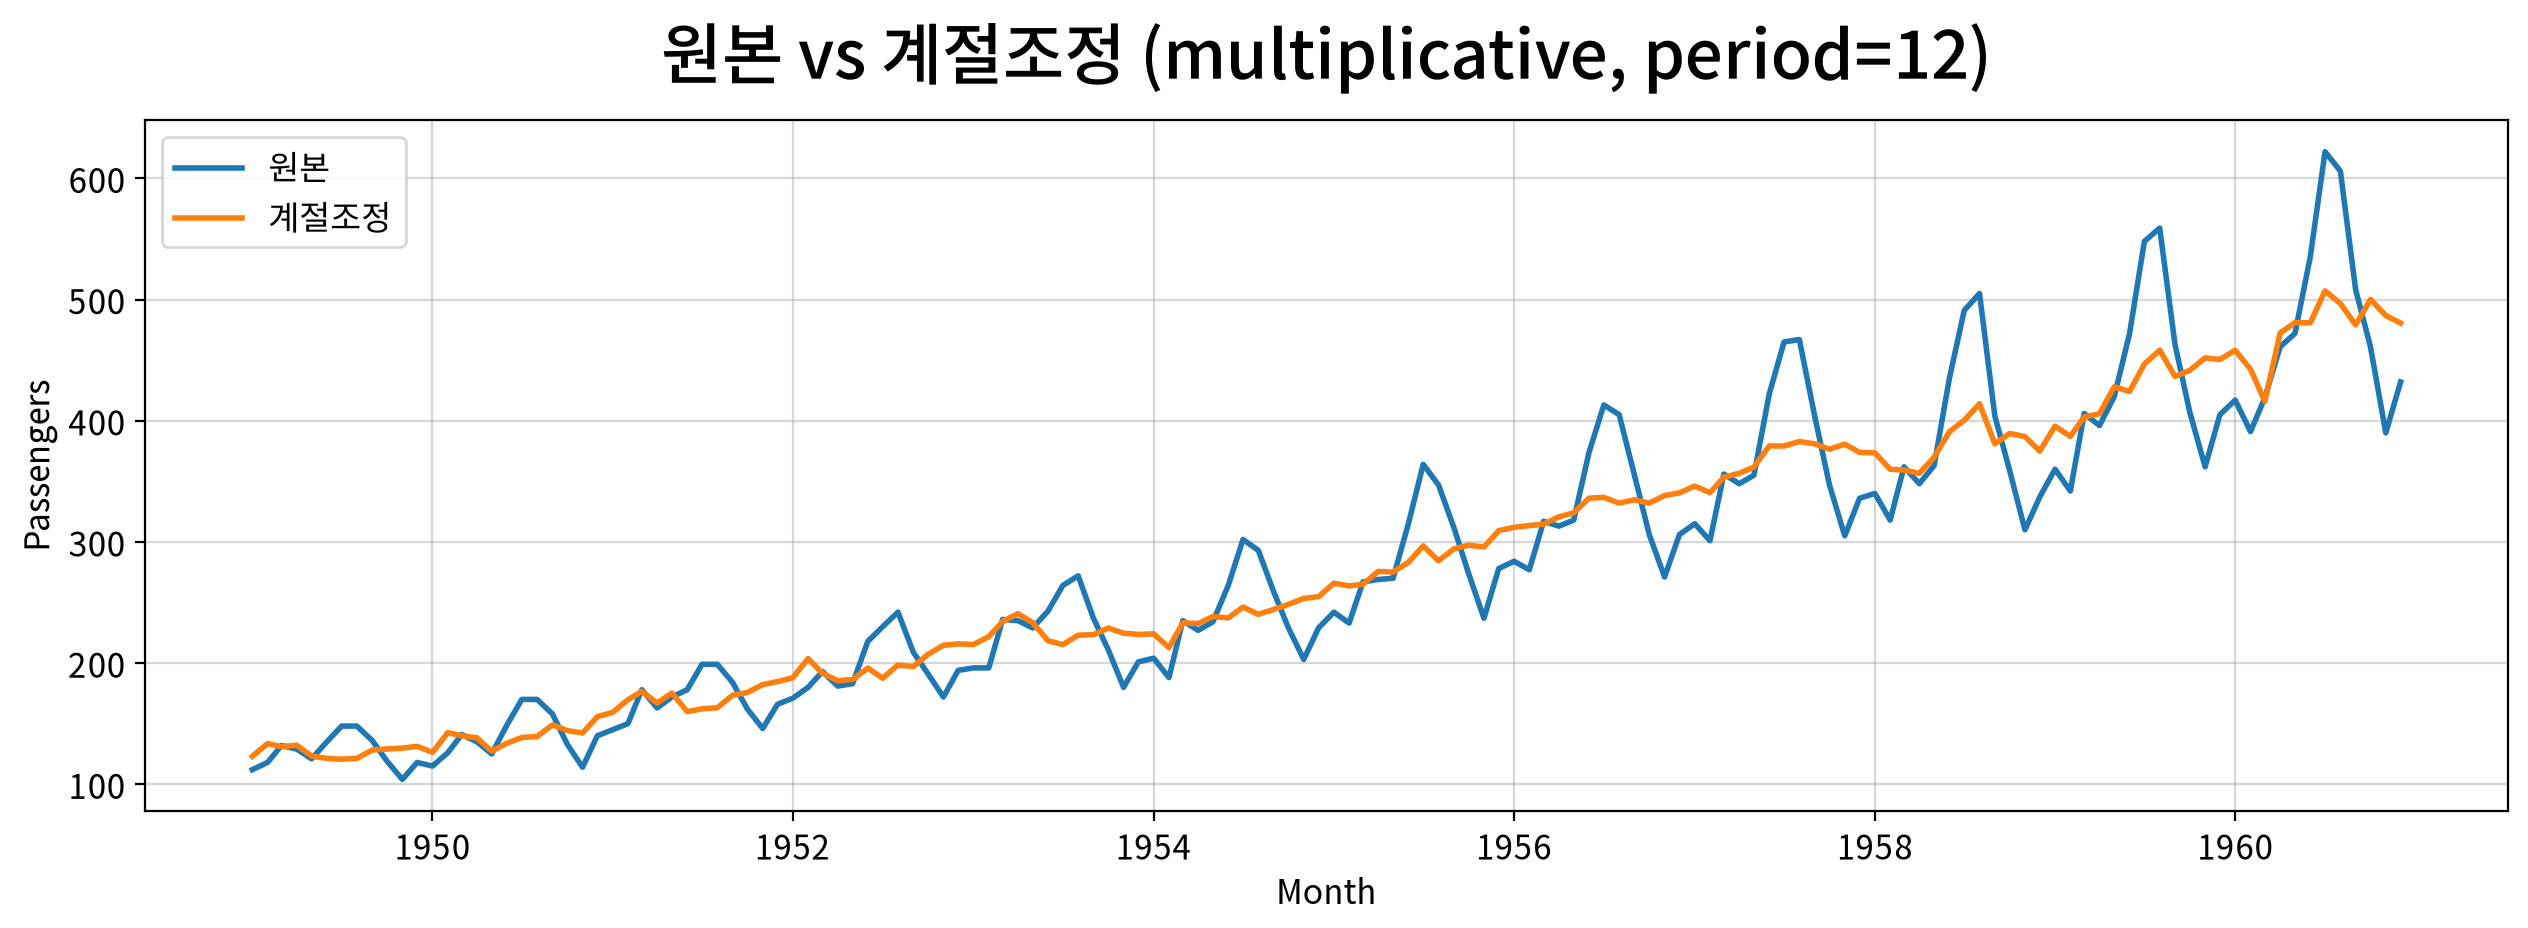

Month
1949-01-01   123.046
1949-02-01   133.541
1949-03-01   131.035
Freq: MS, dtype: float64

In [13]:
adjusted = my_ts.adjust_seasonal(df, 12, "Passengers")
adjusted.head(3)

## # 연습문제 

In [28]:
from jussam import load_data
from helpers import *

In [21]:
origin =  load_data("temperatures_seoul")
origin.head()

📚 1973년 1월부터 2023년 8월까지 서울의 월평균 기온 데이터 (출처: 기상청)


,날짜,평균기온(℃)
0,1973-07-01,26.816
1,1973-08-01,25.884
2,1973-09-01,20.323
3,1973-10-01,13.039
4,1973-11-01,4.723


In [23]:
# 월단위 데이터임을 알림 -> freq = "MS" (Month Start)   
df = my_ts.set_index(origin, "날짜", freq="MS")
print("인덱스 간격(freq) : ", df.index.freqstr)
df.head()

인덱스 간격(freq) :  MS


,평균기온(℃)
날짜,
1973-07-01,26.816
1973-08-01,25.884
1973-09-01,20.323
1973-10-01,13.039
1973-11-01,4.723


In [24]:
# 기간 단위 (기본 freq="YE" -> 연 단위)로 묶어 평균, 표준편차, 변동계수를 계산한다. 
# 변동계수 = 표준편차 / 평균 . 승법이면 이 값이 일정하다. 
# 판정 문장은 함수가 출력하고, 표는 반환되므로 마지막 줄에 놓아 화면에 띄운다. 
my_ts.report_variation(df, "평균기온(℃)", freq="YE")

표준편차 최대/최소: 1.31배
변동계수 최대/최소: 1.43배
판정: 변동폭이 일정하다 -> 원본 사용 가능 / 가법(additive) 모델


,평균,표준편차,변동계수
기간,,,
1973-12-31,14.635,11.985,0.819
1974-12-31,11.080,10.135,0.915
1975-12-31,12.456,10.690,0.858
1976-12-31,11.461,9.642,0.841
1977-12-31,12.293,10.949,0.891
1978-12-31,12.362,10.562,0.854
1979-12-31,12.433,9.348,0.752
1980-12-31,10.794,10.327,0.957
1981-12-31,11.158,10.872,0.974


결합 방식 자동 판정: additive
관측치 602개 중 추세, 잔차가 계산된 구간 590개


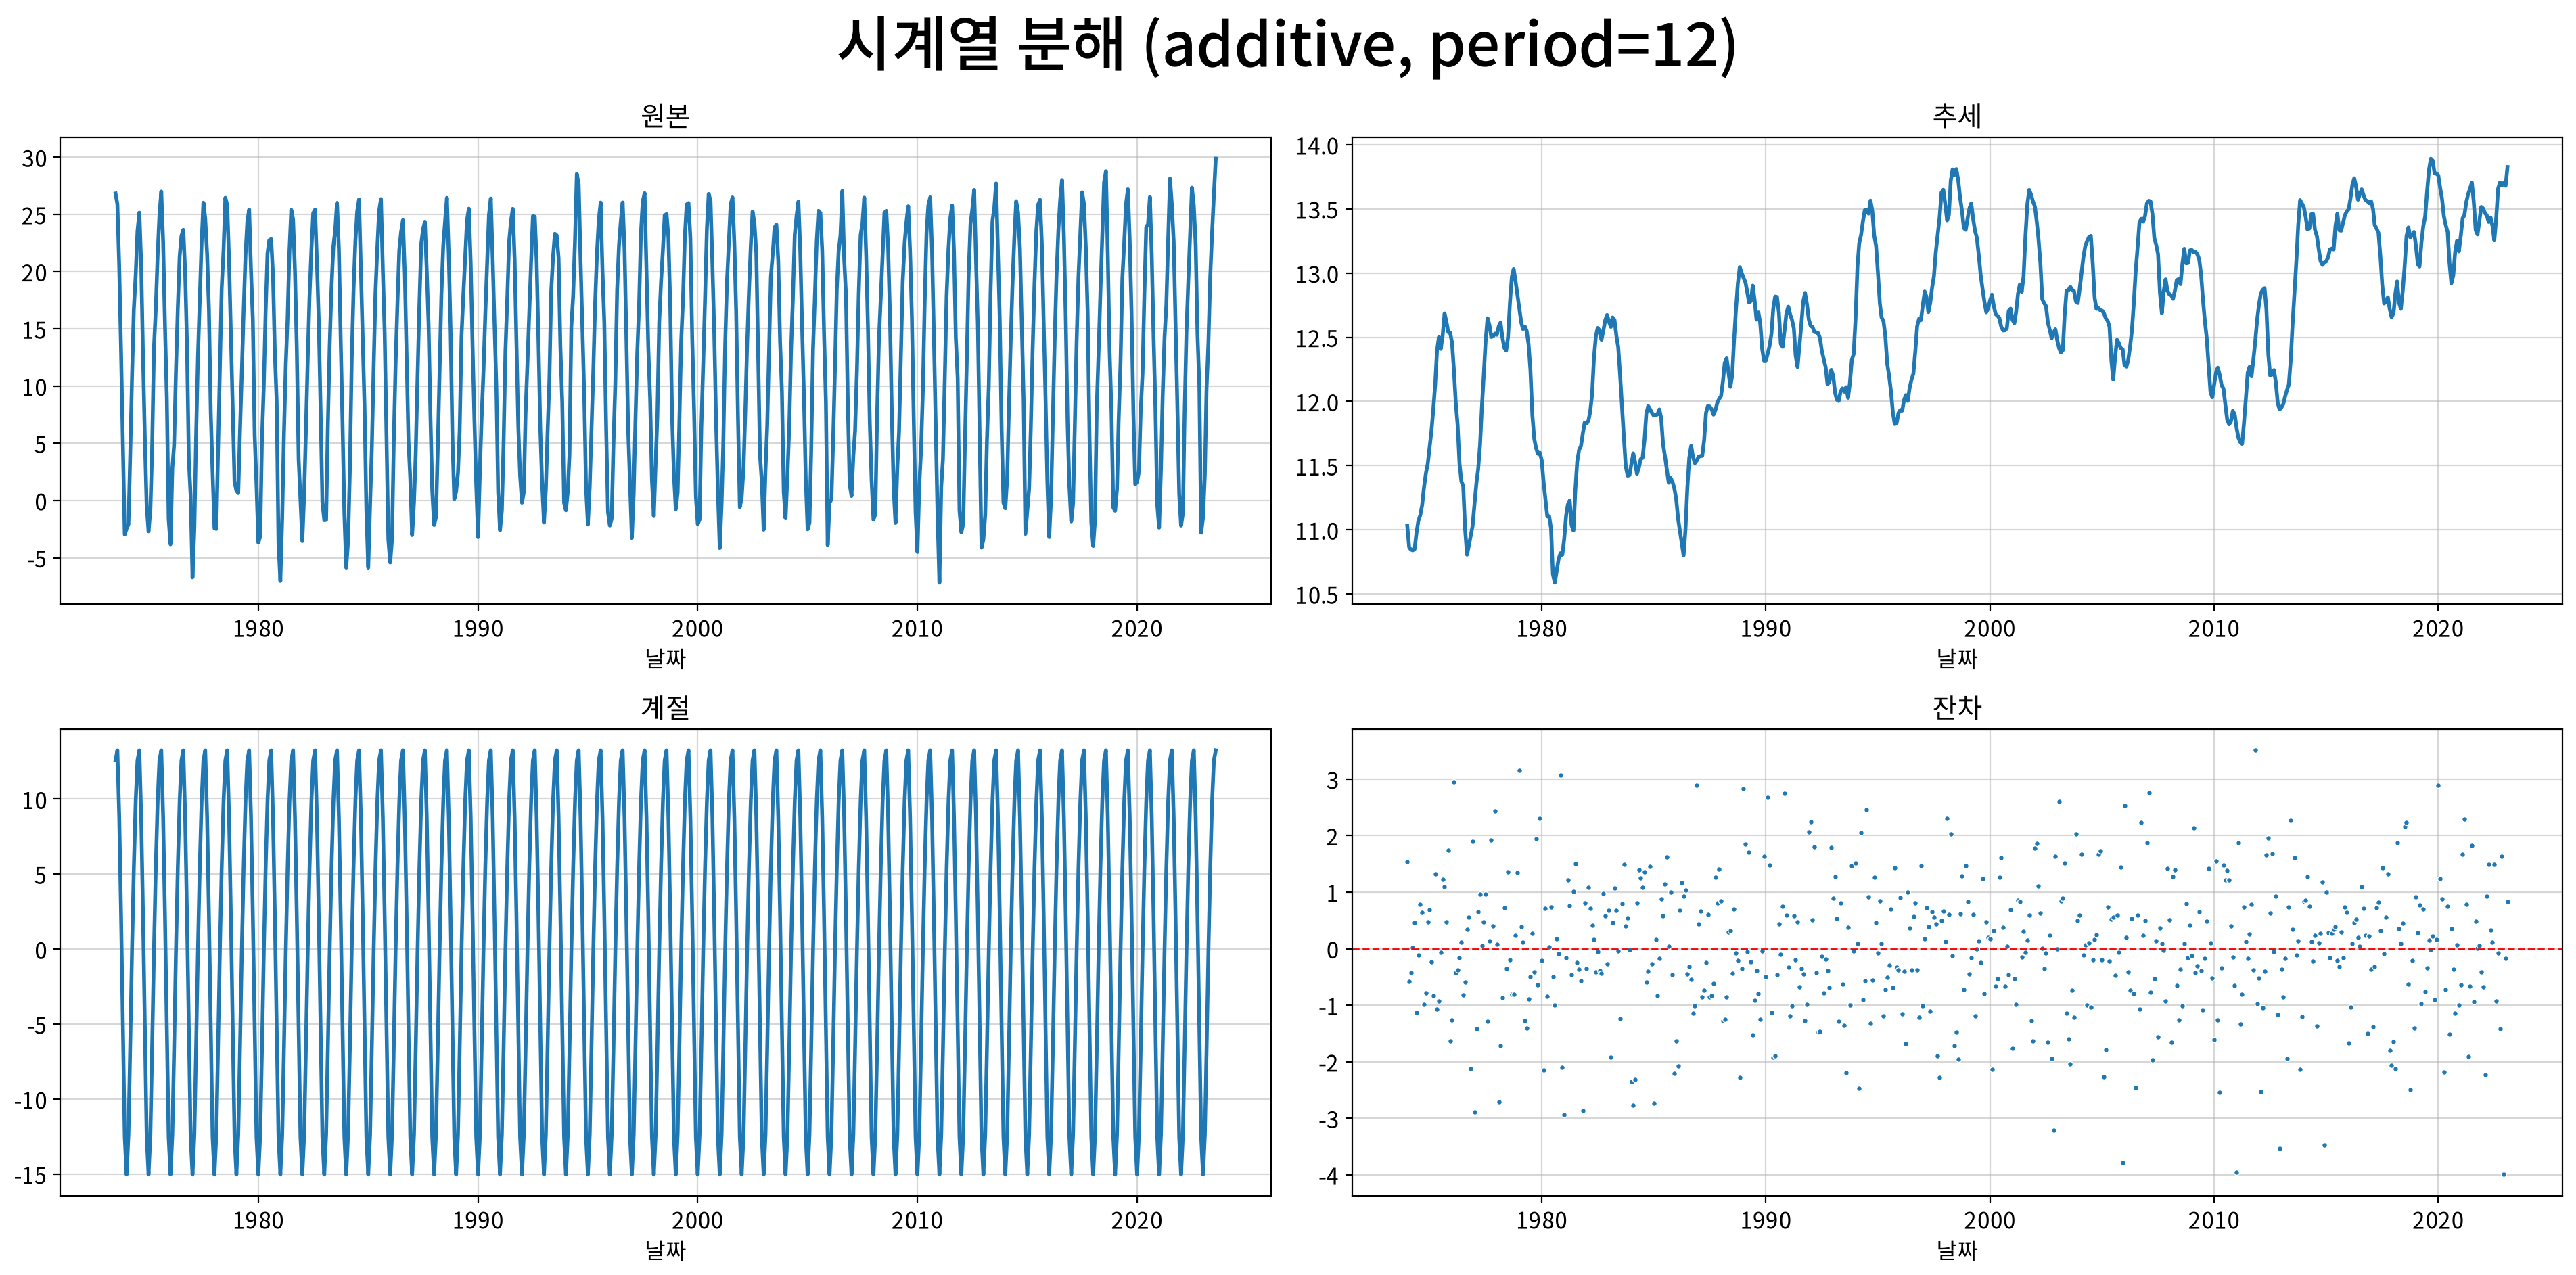

,원본,추세,계절,잔차
날짜,,,,
1974-01-01,-2.458,11.031,-15.024,1.535
1974-02-01,-2.079,10.864,-12.361,-0.582
1974-03-01,3.687,10.845,-6.728,-0.430


In [25]:
# model을 주지 않으면 가법/승법을 스스로 판정한다 
result = my_ts.decompose(df, 12, "평균기온(℃)")

# 표는 화면에 뿌려지지 않고 반환되므로, 보고 싶으면 마지막 줄에 놓는다. 
result.dropna().head(3)

결합 방식: additive
최고 위치: 2 (13.2459)
최저 위치: 7 (-15.0241)


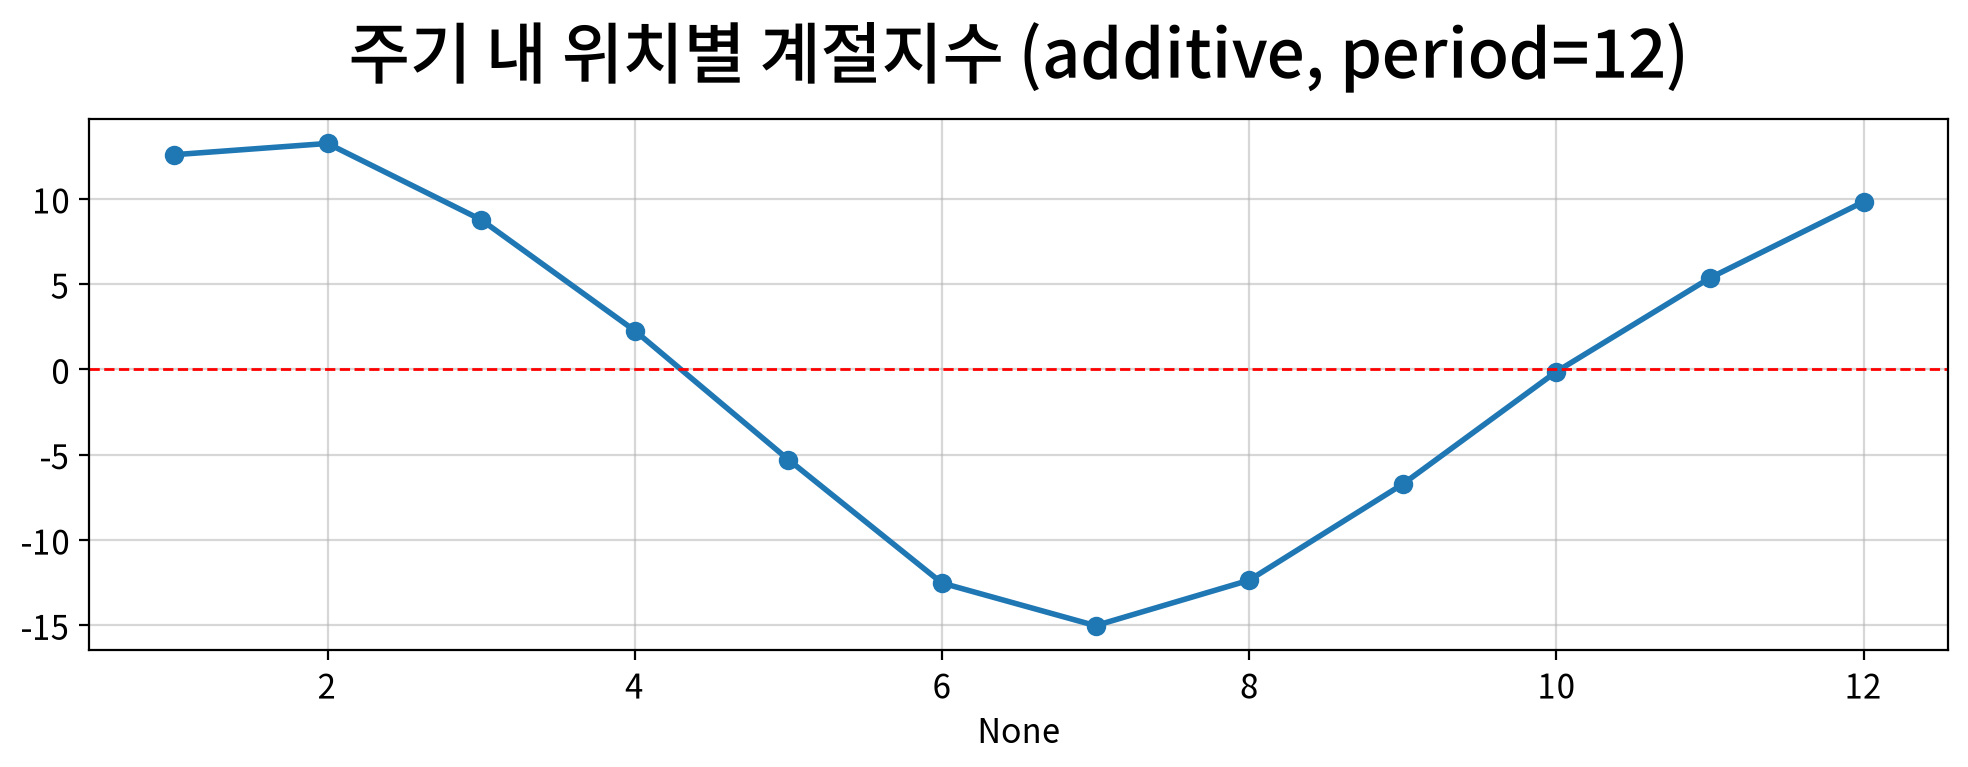

주기 내 위치,1,2,3,4,5,6,7,8,9,10,11,12
계절지수,12.584,13.246,8.773,2.273,-5.288,-12.524,-15.024,-12.361,-6.728,-0.136,5.360,9.824
평균,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000
기준 대비,12.584,13.246,8.773,2.273,-5.288,-12.524,-15.024,-12.361,-6.728,-0.136,5.360,9.824


In [26]:
ss = my_ts.report_seasonal(df, 12, "평균기온(℃)")
ss.T

결합방식: additive (원본 - 계절)


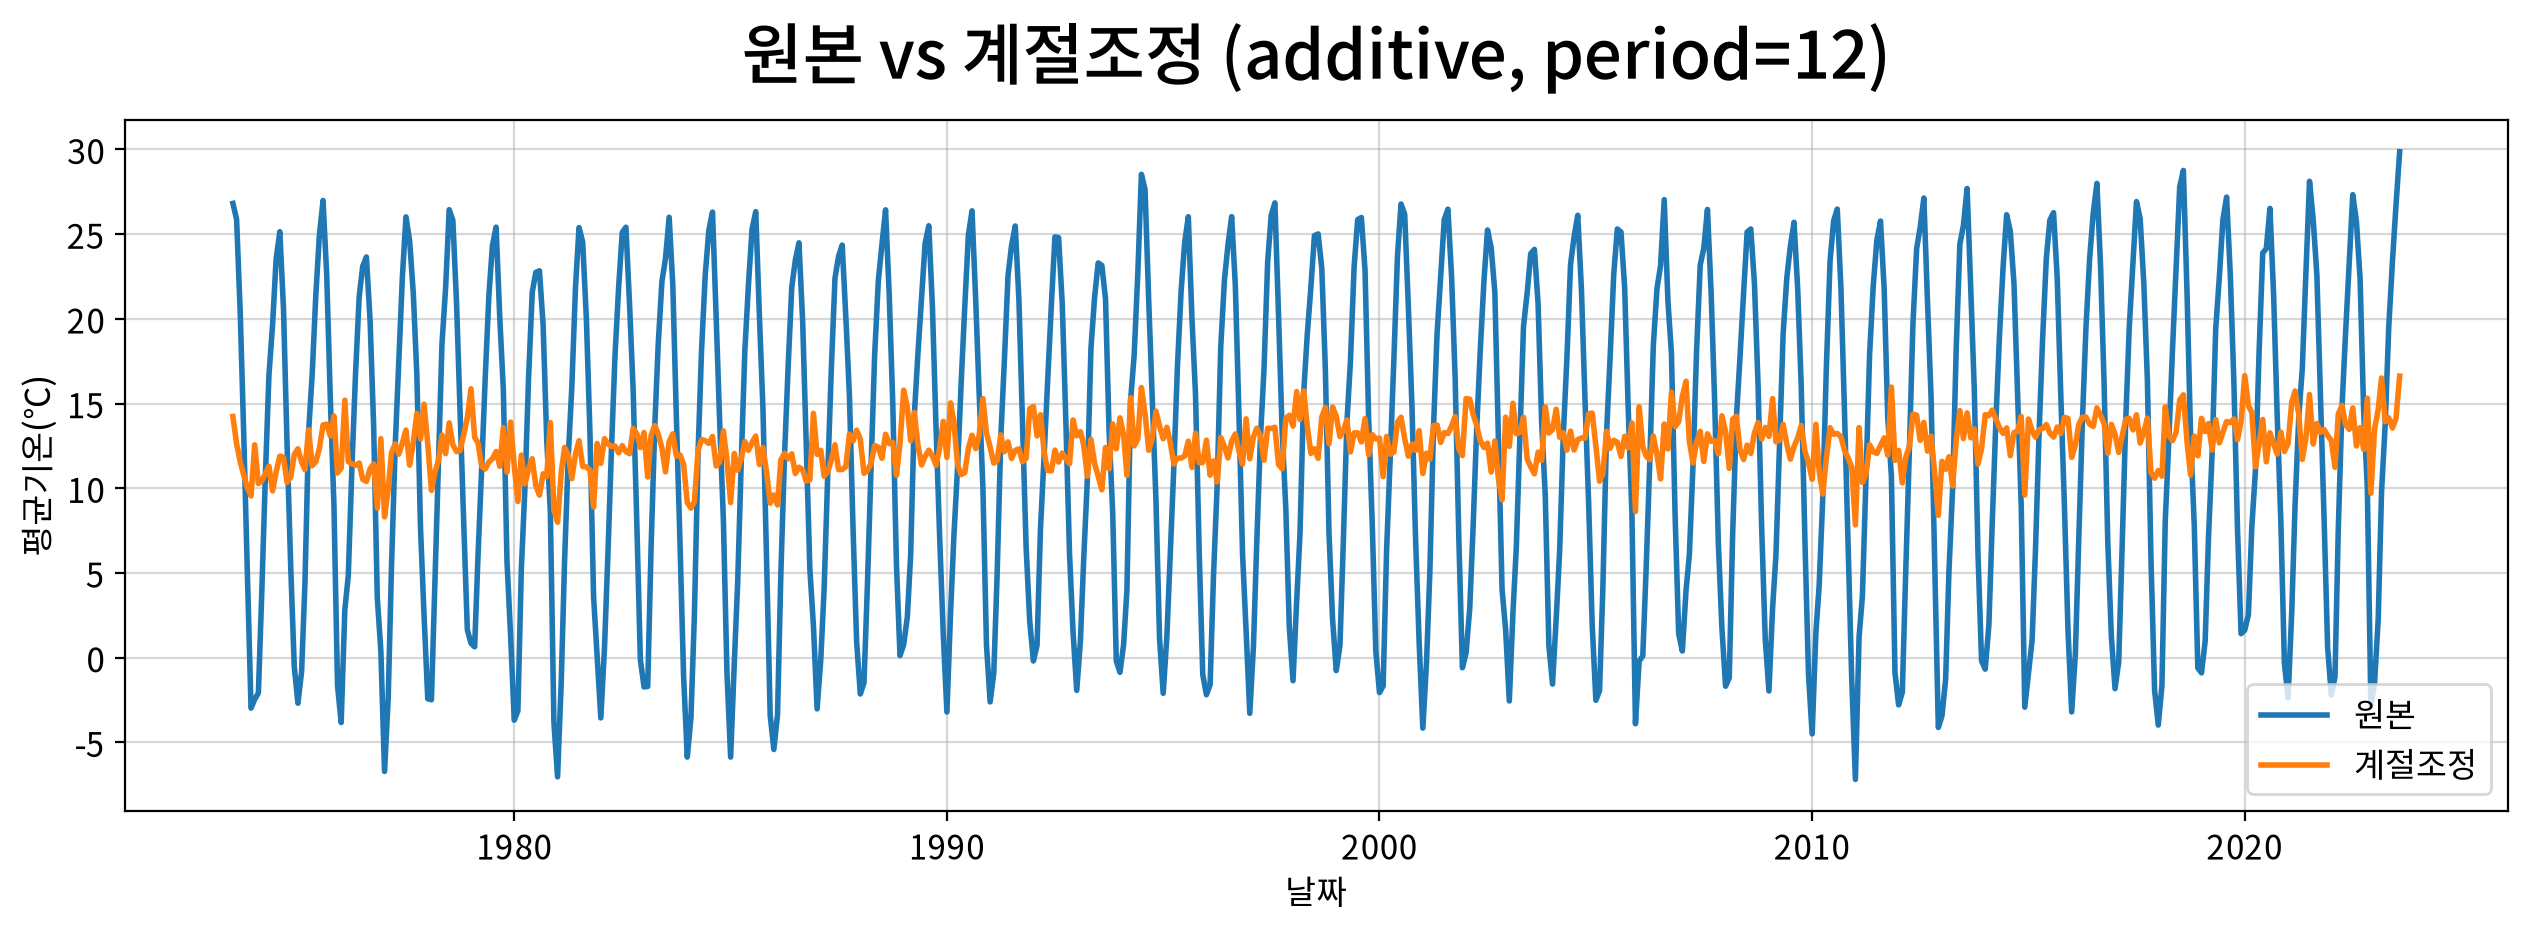

날짜
1973-07-01   14.232
1973-08-01   12.638
1973-09-01   11.550
Freq: MS, dtype: float64

In [27]:
adjusted = my_ts.adjust_seasonal(df, 12, "평균기온(℃)")
adjusted.head(3)